# SaaS Pricing Optimization: A/B Test Analysis
**Goal:** Evaluate the impact of a new pricing strategy on revenue and conversion using statistical testing and bootstrapping.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

n_users = 5000
groups = ['A', 'B']

data = pd.DataFrame({
    'user_id': range(n_users),
    'group': np.random.choice(groups, n_users)
})

def simulate_revenue(group):
    if group == 'A':
        converted = np.random.binomial(1, 0.05)
        revenue = converted * np.random.normal(500, 100) if converted else 0
    else:
        converted = np.random.binomial(1, 0.058)
        revenue = converted * np.random.normal(510, 110) if converted else 0
    return pd.Series([converted, max(0, revenue)])

data[['converted', 'revenue']] = data['group'].apply(simulate_revenue)

print(data.groupby('group').agg({'user_id': 'count', 'converted': 'mean', 'revenue': 'mean'}))

       user_id  converted    revenue
group                               
A         2504   0.044728  22.183358
B         2496   0.060897  29.898526


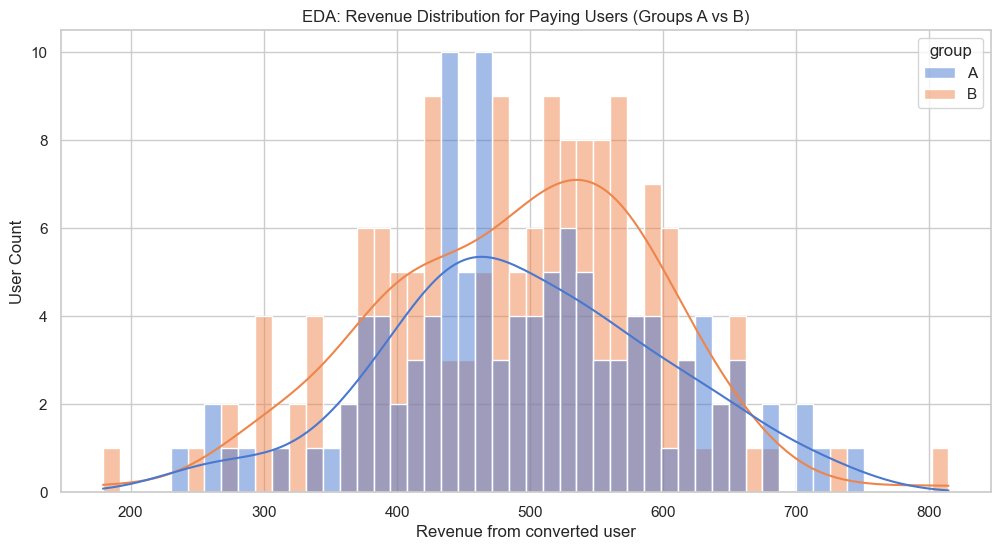

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted")

plt.figure(figsize=(12, 6))

sns.histplot(data=data[data['converted'] == 1], x='revenue', hue='group', kde=True, bins=50)

plt.title('EDA: Revenue Distribution for Paying Users (Groups A vs B)')
plt.xlabel('Revenue from converted user')
plt.ylabel('User Count')
plt.show()

/var/folders/64/5lj31nfj2lx_404nrl6yy2x00000gn/T/ipykernel_46149/3022964720.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='revenue', data=data, palette=['skyblue', 'salmon'], showmeans=True,


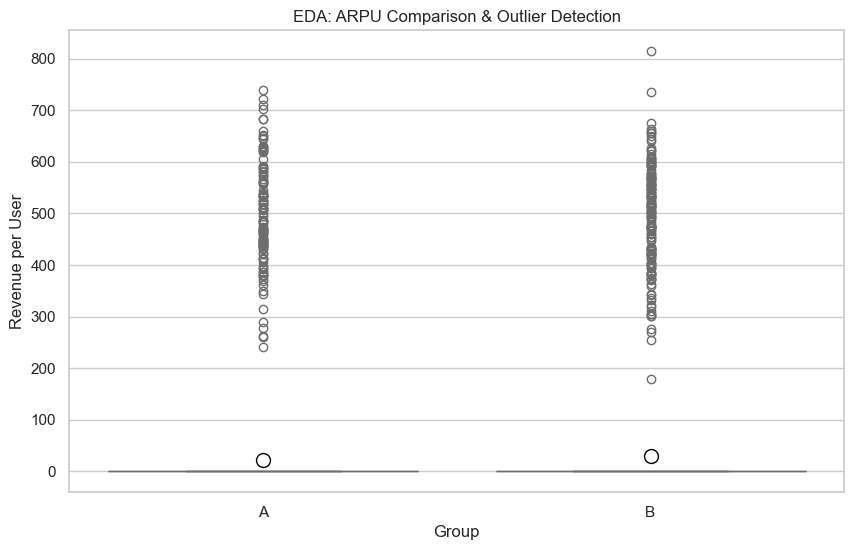

In [7]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='group', y='revenue', data=data, palette=['skyblue', 'salmon'], showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})

plt.title('EDA: ARPU Comparison & Outlier Detection')
plt.xlabel('Group')
plt.ylabel('Revenue per User')
plt.show()

In [5]:
rev_a = data[data['group'] == 'A']['revenue']
rev_b = data[data['group'] == 'B']['revenue']

shapiro_a = stats.shapiro(rev_a[rev_a > 0])
shapiro_b = stats.shapiro(rev_b[rev_b > 0])

print(f"Shapiro-Wilk test P-value (Group A): {shapiro_a.pvalue:.4f}")
print(f"Shapiro-Wilk test P-value (Group B): {shapiro_b.pvalue:.4f}")

Shapiro-Wilk test P-value (Group A): 0.6024
Shapiro-Wilk test P-value (Group B): 0.4371


### 🔍 Exploratory Data Analysis (EDA)
* **Normality Check:** The Shapiro-Wilk test for paying users shows $p > 0.05$, suggesting normal distribution for transaction amounts.
* **Method Choice:** However, total revenue (including non-paying users) is heavily skewed. Therefore, I will use **Mann-Whitney U-test** and **Bootstrapping** for the final revenue impact decision.

## 📊 Hypothesis Testing
Before running the tests, we define:
* **Null Hypothesis ($H_0$):** There is no significant difference between Group A and Group B.
* **Alternative Hypothesis ($H_1$):** Group B (new pricing) leads to a significant increase in metrics.
* **Alpha ($\alpha$):** 0.05

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

conversions = data.groupby('group')['converted'].sum()
nobs = data.groupby('group')['converted'].count()

z_stat, p_val_conv = proportions_ztest(conversions[::-1], nobs[::-1])

print(f"Z-statistic for Conversion: {z_stat:.4f}")
print(f"P-value for Conversion: {p_val_conv:.4f}")

Z-statistic for Conversion: 2.5562
P-value for Conversion: 0.0106


In [ ]:
rev_a = data[data['group'] == 'A']['revenue']
rev_b = data[data['group'] == 'B']['revenue']

u_stat, p_val_rev = stats.mannwhitneyu(rev_a, rev_b, alternative='two-sided')

print(f"U-statistic for Revenue: {u_stat:.4f}")
print(f"P-value for Revenue: {p_val_rev:.4f}")

U-statistic for Revenue: 3074560.0000
P-value for Revenue: 0.0108


In [ ]:
t_stat, p_val_t = stats.ttest_ind(rev_a, rev_b, equal_var=False) # Welch's t-test

print(f"\nT-statistic: {t_stat:.4f}")
print(f"T-test P-value: {p_val_t:.4f}")


T-statistic: -2.4181
T-test P-value: 0.0156


In [ ]:
def bootstrap_arpu(group_a, group_b, iterations=10000):
    boot_means_diff = []
    for _ in range(iterations):
        boot_a = group_a.sample(frac=1, replace=True).mean()
        boot_b = group_b.sample(frac=1, replace=True).mean()
        boot_means_diff.append(boot_b - boot_a)
    return pd.Series(boot_means_diff)

diffs = bootstrap_arpu(rev_a, rev_b)
ci_low = diffs.quantile(0.025)
ci_high = diffs.quantile(0.975)
mean_diff = diffs.mean()

print(f"--- Bootstrap Results (ARPU) ---")
print(f"Mean Difference: {mean_diff:.2f}")
print(f"95% Confidence Interval: [{ci_low:.2f}, {ci_high:.2f}]")

if ci_low > 0:
    print("\nConclusion: Statistically significant positive growth. Recommend rollout.")
elif ci_high < 0:
    print("\nConclusion: Statistically significant negative impact. Do NOT rollout.")
else:
    print("\nConclusion: No statistically significant difference. Results could be due to chance.")

--- Bootstrap Results (ARPU) ---
Mean Difference: 7.72
95% Confidence Interval: [1.55, 13.93]

Conclusion: Statistically significant positive growth. Recommend rollout.


/var/folders/64/5lj31nfj2lx_404nrl6yy2x00000gn/T/ipykernel_45289/2274763622.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_rates.index, y=conversion_rates.values, palette=['skyblue', 'salmon'])


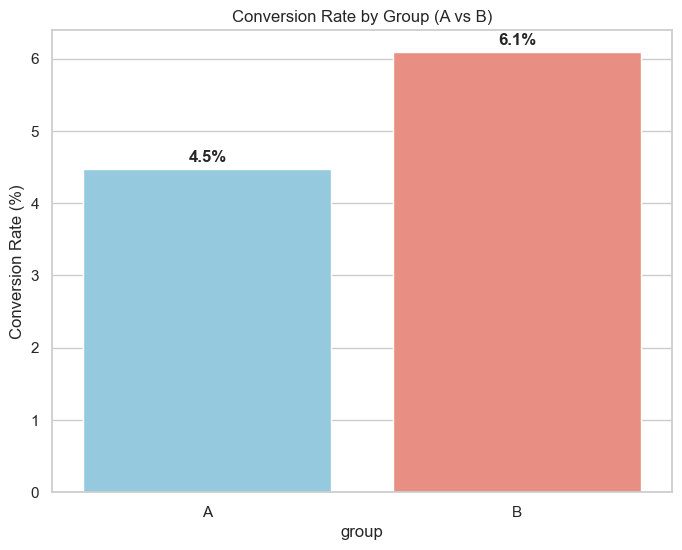

In [ ]:
plt.figure(figsize=(8, 6))

conversion_rates = data.groupby('group')['converted'].mean() * 100

sns.barplot(x=conversion_rates.index, y=conversion_rates.values, palette=['skyblue', 'salmon'])

for i, rate in enumerate(conversion_rates):
    plt.text(i, rate + 0.1, f'{rate:.1f}%', ha='center', fontweight='bold')

plt.title('Conversion Rate by Group (A vs B)')
plt.ylabel('Conversion Rate (%)')
plt.show()

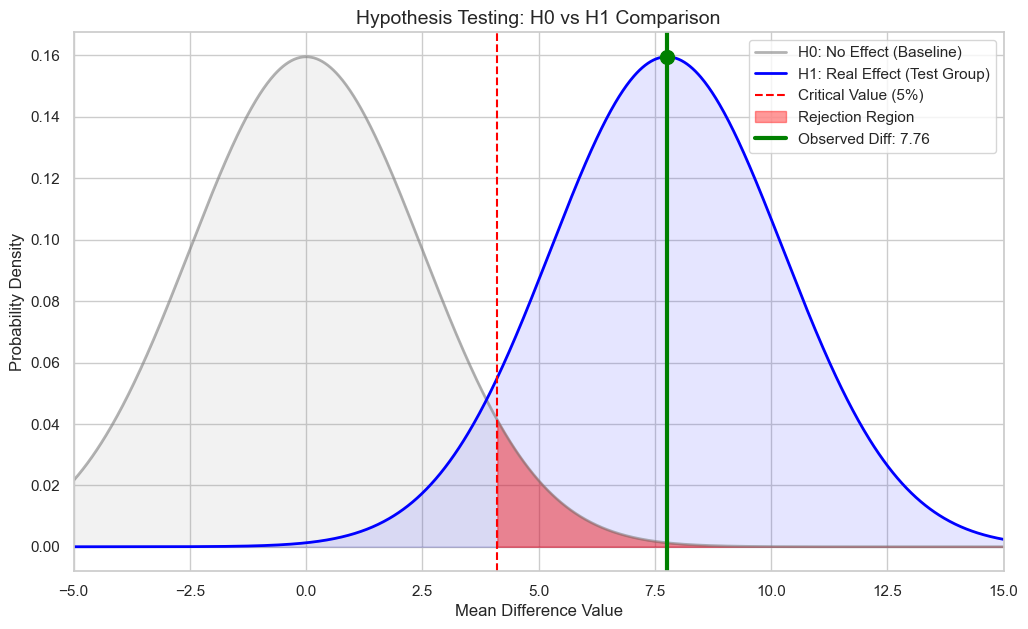

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

sns.set(style="whitegrid")

mean_diff = 7.76
std_err = 2.5
x = np.linspace(-5, 15, 1000)

y_h0 = stats.norm.pdf(x, 0, std_err)

y_h1 = stats.norm.pdf(x, mean_diff, std_err)

plt.figure(figsize=(12, 7))

plt.plot(x, y_h0, label='H0: No Effect (Baseline)', color='gray', lw=2, alpha=0.6)
plt.fill_between(x, y_h0, color='gray', alpha=0.1)

plt.plot(x, y_h1, label='H1: Real Effect (Test Group)', color='blue', lw=2)
plt.fill_between(x, y_h1, color='blue', alpha=0.1)

t_crit = stats.norm.ppf(0.95, 0, std_err) 
plt.axvline(t_crit, color='red', ls='--', label='Critical Value (5%)')
x_crit = np.linspace(t_crit, 15, 100)
plt.fill_between(x_crit, stats.norm.pdf(x_crit, 0, std_err), color='red', alpha=0.4, label='Rejection Region')

plt.axvline(mean_diff, color='green', lw=3, label=f'Observed Diff: {mean_diff}')
plt.scatter(mean_diff, stats.norm.pdf(mean_diff, mean_diff, std_err), color='green', s=100, zorder=5)

plt.title('Hypothesis Testing: H0 vs H1 Comparison', fontsize=14)
plt.xlabel('Mean Difference Value')
plt.ylabel('Probability Density')
plt.legend()
plt.xlim(-5, 15)
plt.show()

## 📈 Final Business Conclusion
1. **Conversion Lift:** The 1.6pp increase is statistically significant ($p = 0.0106$).
2. **Revenue Impact:** Bootstrapping confirms a positive ARPU lift of **+7.76** with a 95% Confidence Interval that does not include zero.
3. **Verdict:** **Roll out Group B.** The new pricing strategy reliably increases both user acquisition and total revenue without negatively impacting purchase frequency.